In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import * # noqa
from src.mosaic import * # noqa

## Example with 2 clients

### Generate BN and clients

In [32]:
# Create a baseline model
set_seed()
bn_base = gum.fastBN(f"X<-Y->W->Z; X->Z")

# Generate clients
clients = {}
E, N = 2, 100
for e in range(E):

    # Init the client
    p = 0 if e == 0 else .2
    gt, mask = resample_bn_params(bn_base, prob=p)
    client = Client(gt, mask)

    # Generate data
    client.generate_data(size=N)

    # Learn the BN
    client.learn_bn()

    # Learn CNs
    client.learn_cn(ess=1)

    # Collect
    clients[e] = client

In [33]:
for e in range(E):
    print(f"Client {e}:\n")
    gnb.showCPTs(clients[e].gt)

Client 0:



Client 1:



In [34]:
# Define plot
def plot_update(ax, client_num:int, var: str, parents: dict, cset_update: tuple, prior: tuple = None, p:bool = False):

    client = clients[client_num]
    parents_idx = get_cpt_index(client.bn, var, parents)

    if prior:
        prior_min, prior_max = get_tabular_cpt(prior[0]), get_tabular_cpt(prior[1])
        prior = [prior_min[parents_idx, :], prior_max[parents_idx, :]]
        ax.plot([prior[0][0], prior[1][0]], [prior[1][1], prior[0][1]], "-", 
                color="#52CF5292", linewidth=6, label="Prior")

    cset = client.get_cset(var, parents)
    ax.plot([cset[0][0], cset[1][0]], [cset[1][1], cset[0][1]], "-", 
            color="#2f82ff", linewidth=2, label="Local IDM")

    mle = get_tabular_cpt(client.bn.cpt(var))
    mle = mle[parents_idx,:]
    ax.scatter(mle[0], mle[1], marker="o", s=120, linewidths=.5,
                color="#ffff00", edgecolors="black", label="MLE")

    ax.plot([cset_update[0][0], cset_update[1][0]], [cset_update[1][1], cset_update[0][1]], "-", 
             color="#ff2525b3", linewidth=6, label="Updated Cset")
    
    theta = get_tabular_cpt(client.gt.cpt(var))
    theta = theta[parents_idx,:]
    ax.scatter(theta[0], theta[1], marker="s", s=120, linewidths=.5,
                color="#ffff00", edgecolors="black", label="True param.")
    
    if p:
        print("Cset (IDM):\n", cset)
        print("\nMLE:\n", mle)
        print("\nUpdated cset:\n", cset_update)

    ax.legend(loc="best")

### Plot updates

In [35]:
# fig, axs = plt.subplots(3, 3, figsize=(14 , 10), constrained_layout=True)
# axs_flat = axs.flatten()

# # Choose client
# client_num = 0
# client = clients[client_num]

# # Set prior(s)
# prior_clients_dict = clients.copy()
# prior_clients_dict.pop(client_num)
# prior_clients = list(prior_clients_dict.values())

# # For every variable ...
# ax_idx = 0
# for var in bn_base.names():

#     # ... update the credal set, and ...
#     prior = CsetFusion(var, "ConvComb", "unif")(prior_clients)

#     index = bn_base.cpt(var).topandas().index
#     index_df = index.to_frame(index=False)

#     mask = get_tabular_cpt(prior_clients[0].mask.cpt(var)) # assuming only 1 client forms the prior

#     # ... for every parents configuration ...
#     has_parents = len(bn_base.parents(var)) != 0
#     confs = range(len(index_df)) if has_parents else [0]
#     for i in confs:

#         # ... update the cset, and ...
#         parents = dict(index_df.iloc[i]) if has_parents else None
#         parents_idx = get_cpt_index(bn_base, var, parents)
#         prior_min, prior_max = get_tabular_cpt(prior[0]), get_tabular_cpt(prior[1])
#         cset_update = client.update_cset(var, (prior_min[parents_idx, :], prior_max[parents_idx, :]), parents)

#         # ... plot
#         ax = axs_flat[ax_idx]
#         plot_update(ax, client_num, var, parents, cset_update, (prior_min, prior_max), p=False)

#         are_iid = False if np.any(mask[i, :] == 0) else True 

#         kl_mle = get_kl(client, var, parents)
#         kl_idm = get_kl_cset(client, var, parents, client.get_cset(var, parents))
#         kl_upd = get_kl_cset(client, var, parents, cset_update)

#         ax.set_title(f"{var}|{parents}. IID: {are_iid}\n kl_mle: {kl_mle:.2g}, kl_idm: {kl_idm:.2g}, kl_upd: {kl_upd:.2g}")
        

#         ax_idx += 1

## Example: many IID clients

### Generate BN and clients

In [36]:
# Create a baseline model
set_seed()
bn_base = gum.fastBN(f"X<-Y->W->Z; X->Z")

# Generate clients
clients = {}
E, N = 10, 100
p = 0
for e in range(E):

    # Init the client
    gt, mask = resample_bn_params(bn_base, prob=p)
    client = Client(gt, mask)

    # Generate data
    client.generate_data(size=N)

    # Learn the BN
    client.learn_bn()

    # Learn CNs
    client.learn_cn(ess=1)

    # Collect
    clients[e] = client

### Plot updates

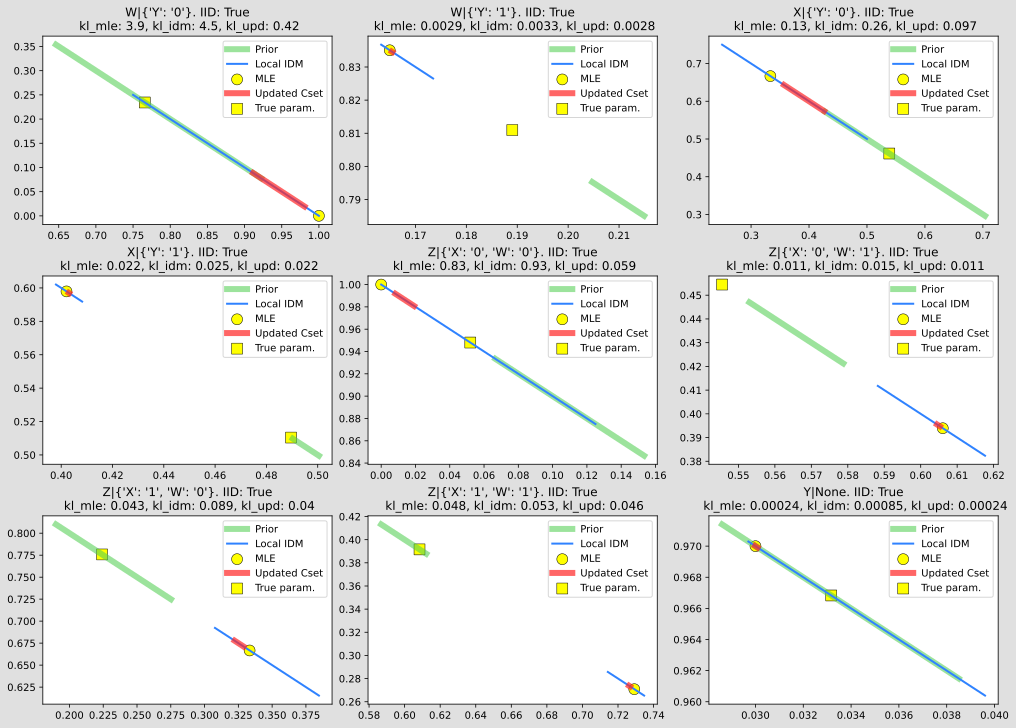

In [37]:
fig, axs = plt.subplots(3, 3, figsize=(14 , 10), constrained_layout=True)
axs_flat = axs.flatten()

# Choose client
client_num = 0
client = clients[client_num]

# Set prior(s)
prior_clients_dict = clients.copy()
prior_clients_dict.pop(client_num)
prior_clients = list(prior_clients_dict.values())

# For every variable ...
ax_idx = 0
for var in bn_base.names():

    # ... update the credal set, and ...
    prior = CsetFusion(var, "ConvComb", "unif")(prior_clients)

    index = bn_base.cpt(var).topandas().index
    index_df = index.to_frame(index=False)

    mask = get_tabular_cpt(prior_clients[0].mask.cpt(var))
    for c in prior_clients[1:]:
        mask *= get_tabular_cpt(c.mask.cpt(var))

    # ... for every parents configuration ...
    has_parents = len(bn_base.parents(var)) != 0
    confs = range(len(index_df)) if has_parents else [0]
    for i in confs:

        # ... update the cset, and ...
        parents = dict(index_df.iloc[i]) if has_parents else None
        parents_idx = get_cpt_index(bn_base, var, parents)
        prior_min, prior_max = get_tabular_cpt(prior[0]), get_tabular_cpt(prior[1])
        cset_update = client.update_cset(var, (prior_min[parents_idx, :], prior_max[parents_idx, :]), parents)

        # ... plot
        ax = axs_flat[ax_idx]
        plot_update(ax, client_num, var, parents, cset_update, (prior_min, prior_max), p=False)

        are_iid = False if np.any(mask[i, :] == 0) else True 

        kl_mle = get_kl(client, var, parents)
        kl_idm = get_kl_cset(client, var, parents, client.get_cset(var, parents))
        kl_upd = get_kl_cset(client, var, parents, cset_update)

        ax.set_title(f"{var}|{parents}. IID: {are_iid}\n kl_mle: {kl_mle:.2g}, kl_idm: {kl_idm:.2g}, kl_upd: {kl_upd:.2g}")
        

        ax_idx += 1